# CAEN Digitizer Plotter

## Imports and Definitions

In [2]:
from helper import *
from caen_digitizer import *

# data
import uproot
import numpy as np
import awkward as ak
import polars as pl

# plotting
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# plot settings, increase font sizes
plt.rcParams.update({
    "figure.figsize": (6,4),
    "font.size": 15, 
    "legend.fontsize": 13, 
    "legend.labelspacing": 0.2, 
    "figure.dpi": 100, 
    "text.usetex": False,
    "text.latex.preamble": r"\usepackage{sfmath}",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

## Read Data

In [ ]:
fileDir = '/home/tianyi/Downloads/bl4s/DATA'

In [49]:
runNo = 1
# data = digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in (17, 27)], signal_filter='converted')
data = digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in range(17, 27)], signal_filter='converted')

In [62]:
active_channels = data.waveforms["wave"][:, 0:6]

In [68]:
signal_max = active_channels.max(axis=2)
signal_min = active_channels.min(axis=2)
signal_max.shape

(10000, 6)

In [75]:
mask_event = (signal_min > -15) & (signal_max > 8)
print(mask_event.shape)

events_mask = np.any(mask_event, axis=1)
print(events_mask.shape)

eff = np.sum(events_mask)/len(events_mask) * 100 
print(f"detection efficiency: {np.sum(events_mask)}/{len(events_mask)} = {eff:0.3f}%")

(10000, 6)
(10000,)
detection efficiency: 1814/10000 = 18.140%


(10000,)
[0 1 2 3 4 6]
[8186  641 1108   46   18    1]
0 channels coincident trigger: 8186/10000 = 81.860%
1 channels coincident trigger: 641/10000 = 6.410%
2 channels coincident trigger: 1108/10000 = 11.080%
3 channels coincident trigger: 46/10000 = 0.460%
4 channels coincident trigger: 18/10000 = 0.180%
6 channels coincident trigger: 1/10000 = 0.010%


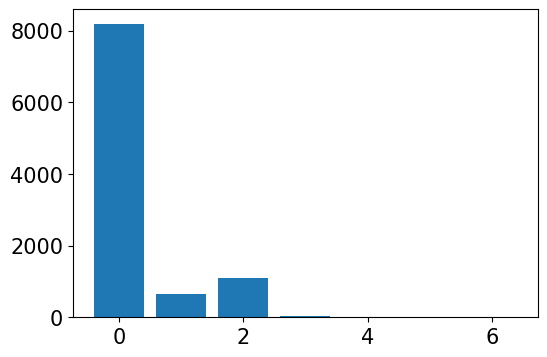

In [82]:
sensor_trigger_distribution = np.sum(mask_event, axis=1)
print(sensor_trigger_distribution.shape)

n_sensor_triggers, counts = np.unique(sensor_trigger_distribution, return_counts=True)
print(n_sensor_triggers)
print(counts)

plt.bar(n_sensor_triggers, counts)

for n_trigger, count in zip(n_sensor_triggers, counts):
    total = len(sensor_trigger_distribution)
    ratio = count / total * 100
    print(f"{n_trigger} channels coincident trigger: {count}/{total} = {ratio:0.3f}%")

In [50]:
_channel_trigger = 3  # trigger channel

# Build mask based on trigger channel
signal_max = data.waveforms['amplitude'][:, _channel_trigger]
signal_min = data.waveforms['wave'][:, _channel_trigger].min(axis=1)
mask_event = (signal_min > -15) & (signal_max > 10)

selected_events = np.where(mask_event)[0]
print(f"{len(selected_events)} signal events of {len(data.waveforms['wave'])} total events")

n = 24
(triggered_event_n,) = np.argwhere(mask_event)[n]
print(triggered_event_n)

mask_event = np.zeros(len(mask_event), dtype=bool)
mask_event[triggered_event_n] = 1

# Plot all 10 channels for masked events
fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)

for ch in range(10):
    ax = axes[ch // 5, ch % 5]
    ax.plot(
        data.waveforms['waveTime'][mask_event, ch].T,
        data.waveforms['wave'][mask_event, ch].T,
        lw=0.5
    )
    ax.set_title(f"Channel {ch}")
    ax.grid(which='major', lw=0.7, ls='-')
    ax.grid(which='minor', lw=0.5, ls=':')
    ax.minorticks_on()

    # Annotate event indices for clarity
    for i, ev_idx in enumerate(selected_events):
        ax.text(0.99, 0.95 - i*0.05, f"{ev_idx}", transform=ax.transAxes,
                fontsize=6, ha='right', va='top')

fig.suptitle(f"Masked events (trigger: ch {_channel_trigger})", fontsize=14)
fig.tight_layout(h_pad=1, w_pad=1)
plt.show()

1557 signal events of 10000 total events
153


/tmp/ipykernel_123648/1440243315.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(h_pad=1, w_pad=1)


KeyboardInterrupt: 

85 signal events of 100 total events


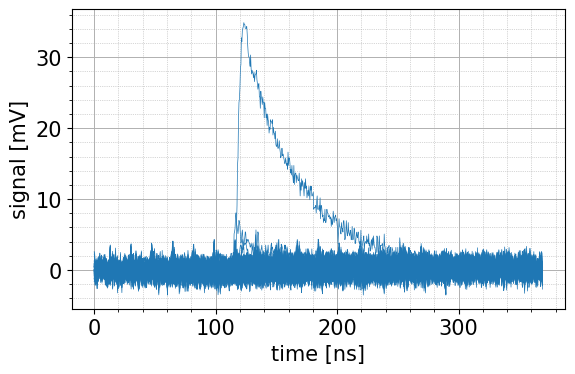

In [29]:
_channel = 0

mask_event = np.zeros((len(data.events)), dtype=bool)
mask_event[4] = True

signal_max = data.waveforms['amplitude'][:,_channel]
signal_min = data.waveforms['wave'][:,_channel].min(axis=1)

mask_event = (signal_min > -15) & (signal_max > 2.5)
# mask_event = (signal_max > 2.5)
# mask_event = (signal_max < 2.5)

print(f"{len(np.where(mask_event == True)[0])} signal events of {len(data.waveforms['wave'])} total events")

fig, ax = plt.subplots()

ax.plot(data.waveforms['waveTime'][mask_event,_channel].T, 
        data.waveforms['wave'][mask_event,_channel].T, 
        'C0-', lw=0.5, label=np.append(np.array(['sipm0']), np.full((len(data.waveforms['waveTime'][mask_event,_channel])-1), None))
       )

ax.set(title='', xlabel='time [ns]', ylabel='signal [mV]')#, xlim=(150,250))
ax.grid(which='major', lw=0.7, ls='-')
ax.grid(which='minor', lw=0.5, ls=':')
ax.minorticks_on()
#leg = ax.legend()
#for line in leg.get_lines():
#    line.set_linewidth(1.5)

fig.tight_layout(h_pad=1, w_pad=1)
# fig.savefig('tmp.pdf')
plt.show()

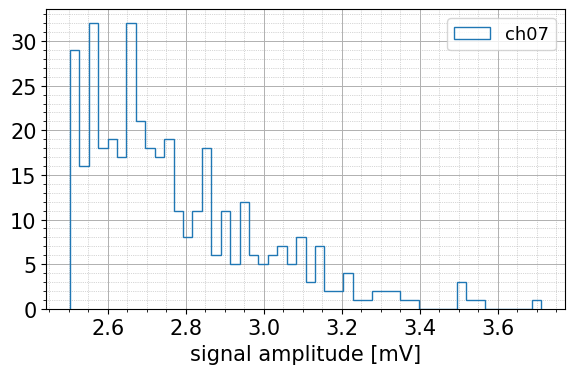

In [12]:
_channel = 7

mask_event = np.zeros((len(data.events)), dtype=bool)
mask_event[:] = True

signal_max = data.waveforms['amplitude'][:,_channel]
signal_min = data.waveforms['wave'][:,_channel].min(axis=1)

mask_event = (signal_min > -15) & (signal_max > 2.5)

fig, ax = plt.subplots()

ax.hist(data.waveforms['amplitude'][mask_event,_channel], 
        bins=50, color='C0', histtype='step', label=f'ch{_channel:02}')

ax.set(title='', xlabel='signal amplitude [mV]', ylabel='', yscale='linear')
ax.grid(which='major', lw=0.7, ls='-')
ax.grid(which='minor', lw=0.5, ls=':')
ax.minorticks_on()
ax.legend()

fig.tight_layout(h_pad=1, w_pad=1)
# fig.savefig('tmp.pdf')
plt.show()

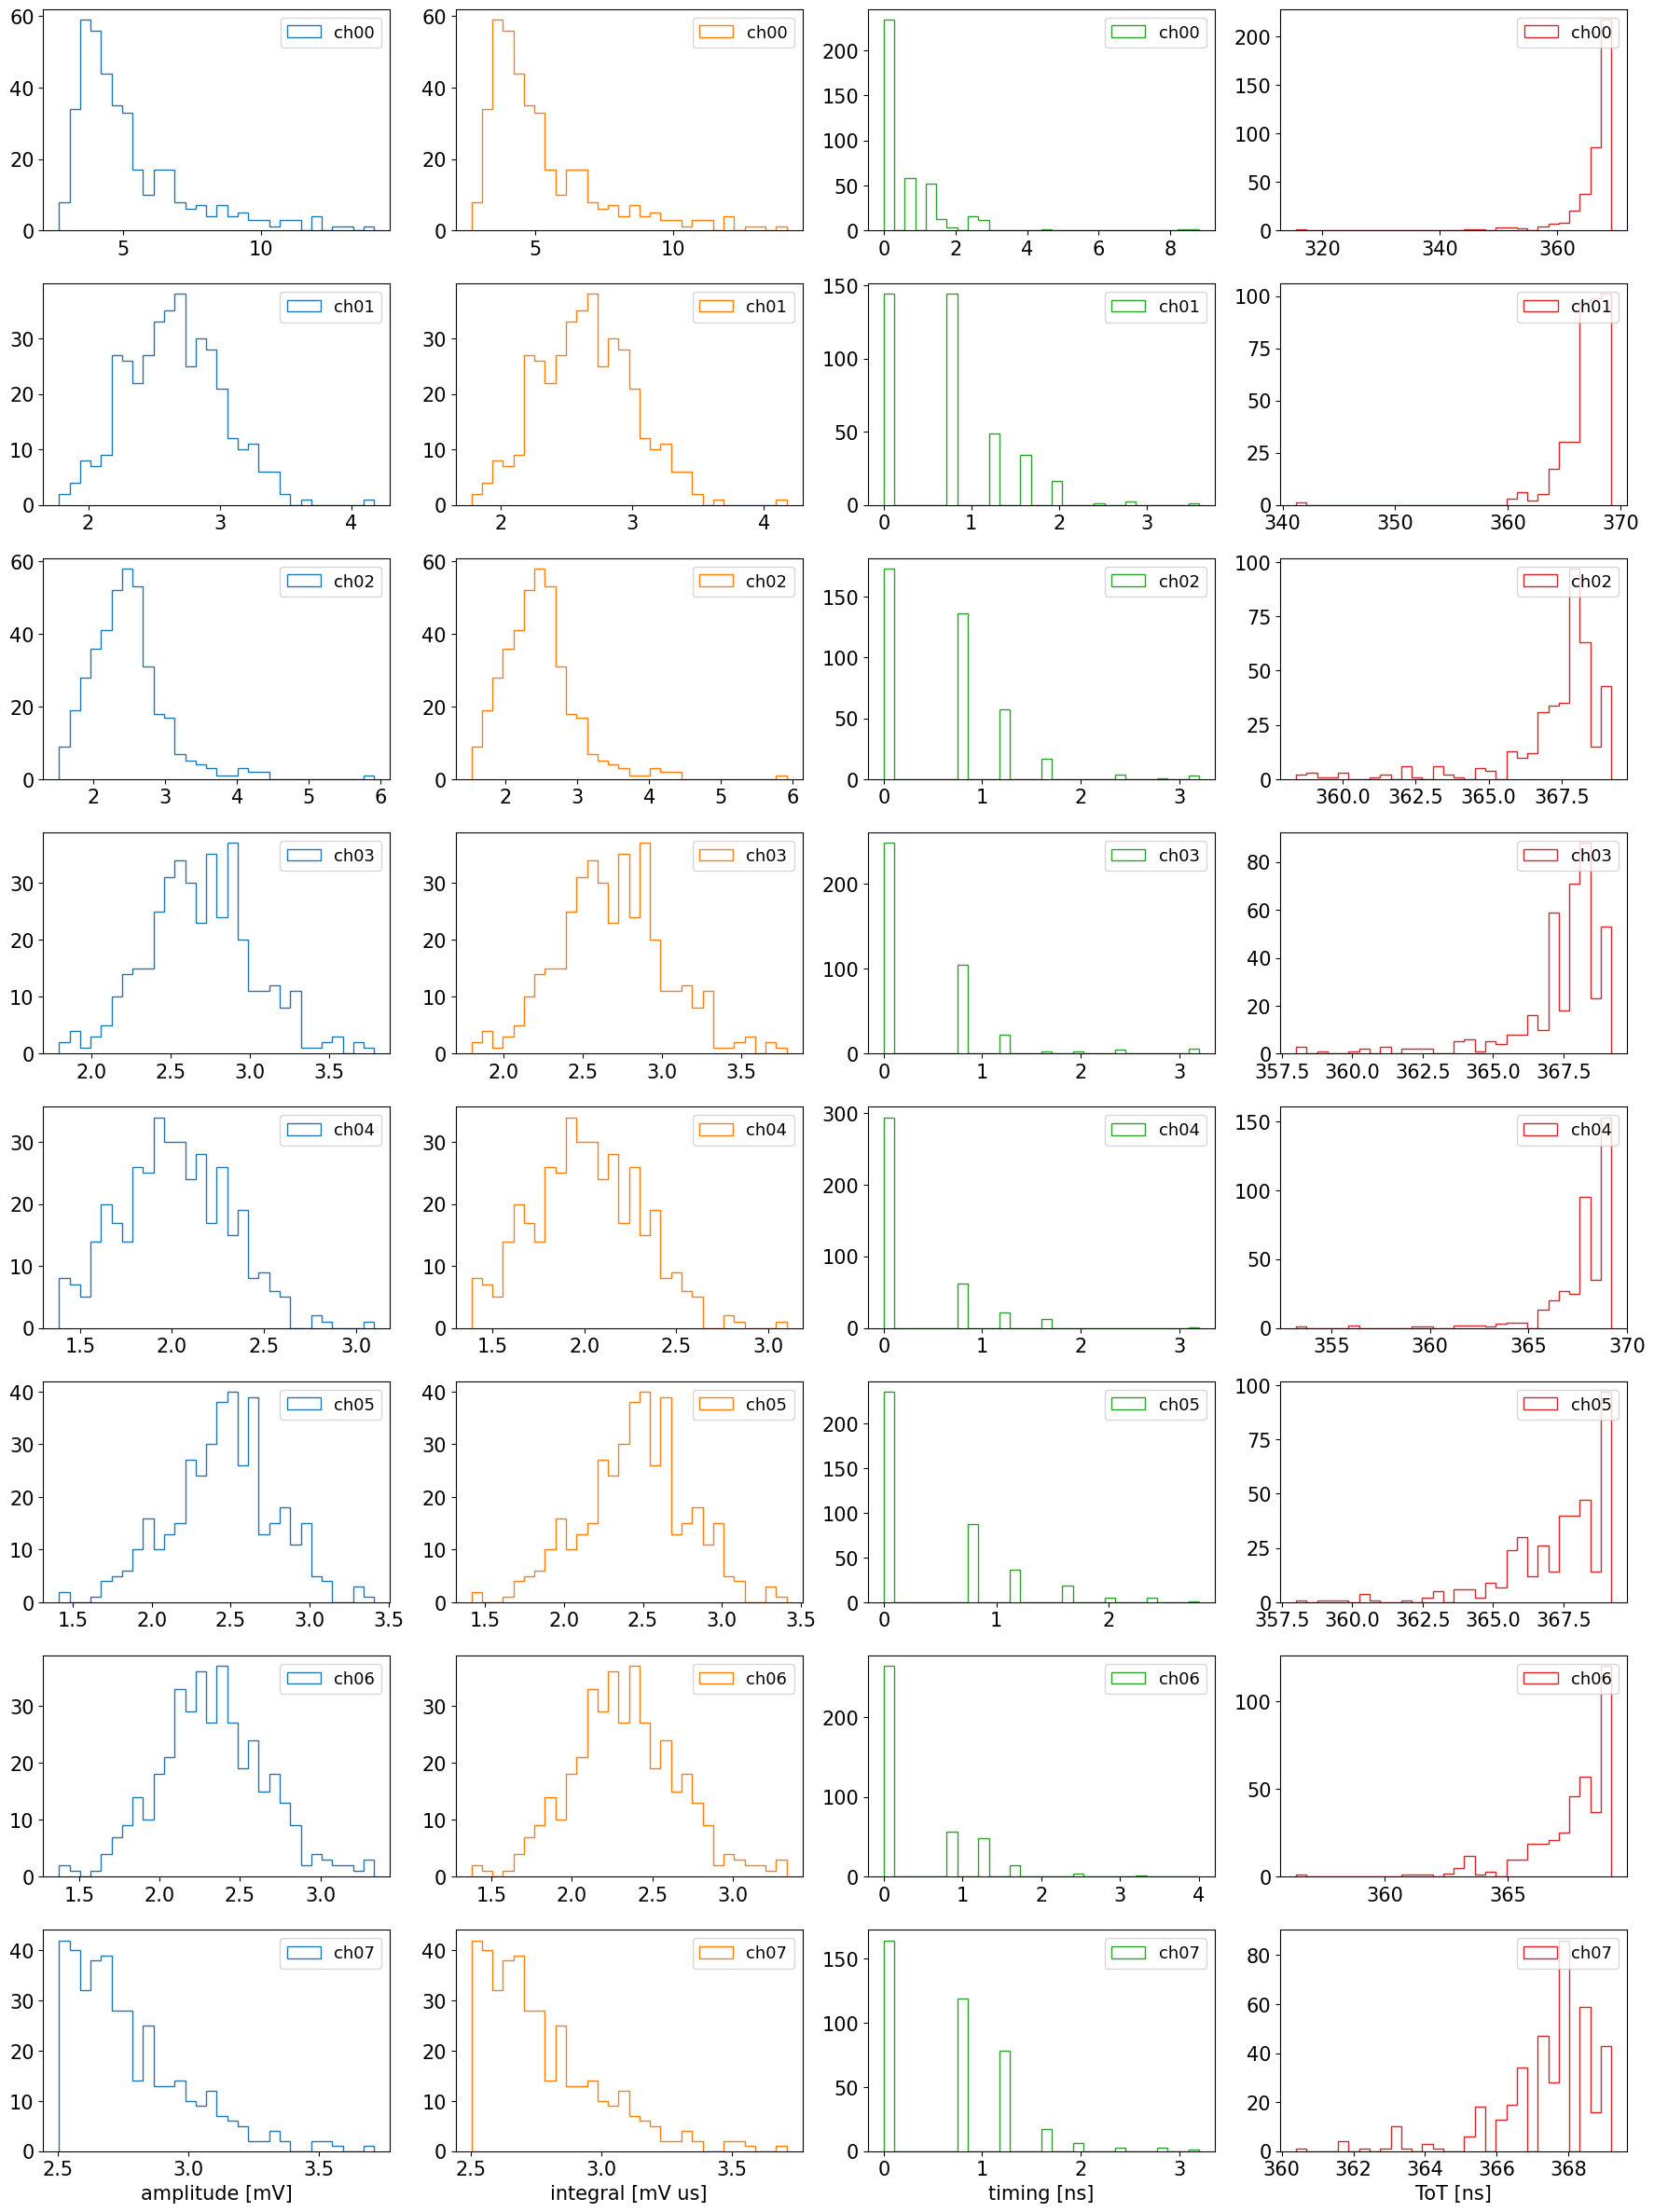

In [13]:
mask_event = np.zeros((len(data.events)), dtype=bool)
mask_event[:] = True

signal_max = data.waveforms['amplitude'][:,_channel]
signal_min = data.waveforms['wave'][:,_channel].min(axis=1)

mask_event = (signal_min > -15) & (signal_max > 2.5)

fig, ax = plt.subplots(len(data.channels), 4, figsize=(18,24))

for ich,ch in enumerate(data.channels):
    ax[ich,0].hist(data.waveforms['amplitude'][mask_event,ich], 
                   bins=30, color='C0', histtype='step', label=f'ch{ch:02}')
    ax[ich,1].hist(data.waveforms['amplitude'][mask_event,ich], 
                   bins=30, color='C1', histtype='step', label=f'ch{ch:02}')
    ax[ich,2].hist(data.waveforms['cft'][mask_event,ich], 
                   bins=30, color='C2', histtype='step', label=f'ch{ch:02}')
    ax[ich,3].hist(data.waveforms['tot'][mask_event,ich], 
                   bins=30, color='C3', histtype='step', label=f'ch{ch:02}')

ax[data.channels[-1],0].set(title='', xlabel='amplitude [mV]', ylabel='')
ax[data.channels[-1],1].set(title='', xlabel='integral [mV us]', ylabel='')
ax[data.channels[-1],2].set(title='', xlabel='timing [ns]', ylabel='')
ax[data.channels[-1],3].set(title='', xlabel='ToT [ns]', ylabel='')


for iax in ax.flatten():
    # iax.grid(which='major', lw=0.7, ls='-')
    # iax.grid(which='minor', lw=0.5, ls=':')
    # iax.minorticks_on()
    iax.legend(loc='upper right')

fig.tight_layout(h_pad=1, w_pad=1)
# fig.savefig('tmp.pdf')
plt.show()

## Tests

In [8]:
import re
with uproot.open(f'{fileDir}/run{21:06}.root') as f:
    tree = f['data']
    list_of_channels = np.asarray([int(re.search(r'ch(\d+)_data', x).group(1)) for x in list(tree.keys()) if re.fullmatch(r'ch\d+_data', x)])
    branches = tree.arrays([f'ch{i}_data' for i in list_of_channels]+['time', 'xinc', 'timestamp'], library='np')
    wave = np.stack(branches[f'ch{0}_data'])
    print(wave)

[[60 60 61 ... 34 31 42]
 [60 60 56 ... 25 30 21]
 [60 60 68 ... 31 28 25]
 ...
 [63 63 62 ... 35 33 42]
 [60 59 52 ... 32 30 26]
 [59 59 59 ... 37 42 30]]


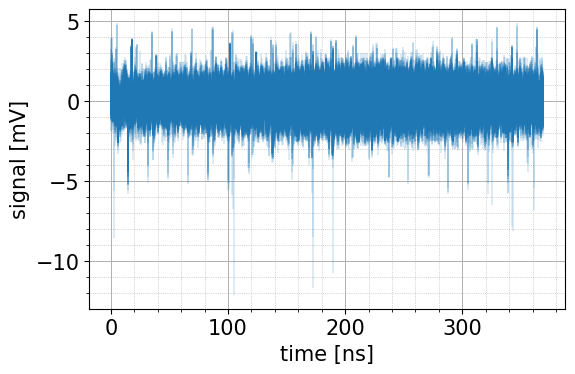

In [9]:
_channel = 0

fig, ax = plt.subplots()

mask_event = np.zeros((len(data.events)), dtype=bool)
mask_event[:] = True
#mask_event = (data.waveforms['amplitude'][:,_channel] > 620)
length_base = 100     #number of points taken to make the baseline
signal = []           #list that will contain the raw-baseline

i=0
for event in data.events:
    if (mask_event[i]):
        baseline = np.average(data.waveforms['wave'][event,_channel].T[0:length_base]) #average over the first length_base points
        signal.append(data.waveforms['wave'][event,_channel].T-baseline)     #subtraction of the baseline and store
        #ax.plot(data.waveforms['waveTime'][mask_event,_channel].T,           #plot the baseline for check
        #baseline*np.ones(len(data.waveforms['waveTime'][mask_event,_channel].T)), 
        #'red', lw=1)
    i+=1

signal = (np.array(signal))

    


ax.plot(data.waveforms['waveTime'][mask_event,_channel], 
      signal, 
      'C0-', lw=0.1)

ax.set(title='', xlabel='time [ns]', ylabel='signal [mV]')#, xlim=(150,250))
#ax.set_ylim(-50,50)
ax.grid(which='major', lw=0.7, ls='-')
ax.grid(which='minor', lw=0.5, ls=':')
ax.minorticks_on()
#leg = ax.legend()
#for line in leg.get_lines():
#    line.set_linewidth(1.5)

fig.tight_layout(h_pad=1, w_pad=1)
# fig.savefig('tmp.pdf')
plt.show()



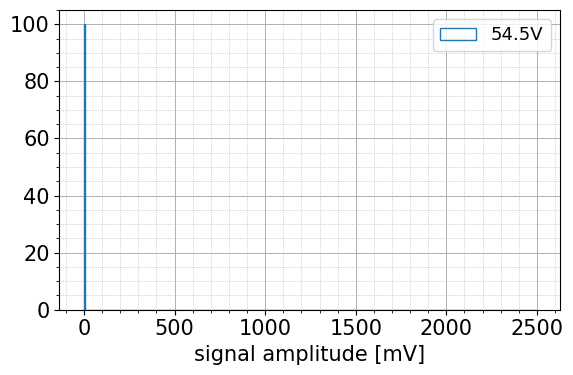

In [10]:
amplitude = np.array([max(x) for x in signal])    #find the maximumaplitude in each event dataset

fig, ax = plt.subplots()

ax.hist(amplitude, 
        bins=500, range=(-10,2500), color='C0', histtype='step', label='54.5V')

#ax.hist(data2.waveforms['amplitude'][mask_event,_channel], 
#        bins=500, range=(0,30), color='C1', histtype='step', label='0V')

ax.set(title='', xlabel='signal amplitude [mV]', ylabel='', yscale='linear')
ax.grid(which='major', lw=0.7, ls='-')
ax.grid(which='minor', lw=0.5, ls=':')
ax.minorticks_on()
ax.legend()

fig.tight_layout(h_pad=1, w_pad=1)
# fig.savefig('tmp.pdf')
plt.show()

In [11]:
_channel = 0

mask_event = np.zeros((len(data.events)), dtype=bool)
mask_event[:] = True

pulse_length = []    #list that will store the pulselength for each event

for i in range(len(data.events)):
    pulse_length.append(data.waveforms['waveTime'][event,_channel][(signal > 0.1*amplitude[:,np.newaxis])[i]][-1] - data.waveforms['waveTime'][event,_channel][(signal > 0.1*amplitude[:,np.newaxis])[i]][0])
    #make the array of [True False] if the sigal is 0.1*max amplitude, use it to mask the waveTime and then subtract the first and last value of the masked times

pulse_length = np.array(pulse_length)

#np.unique(pulse_length.round(2))



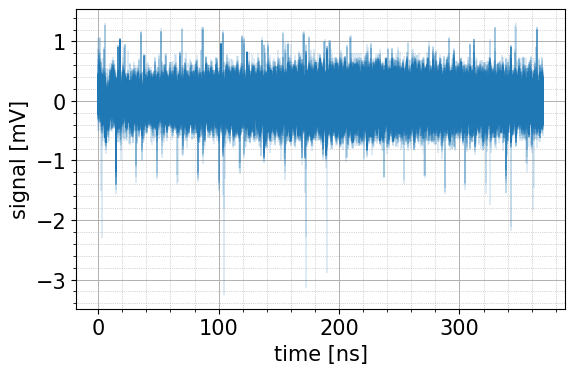

In [12]:
convert = data.adc_conversion*signal     #multiply by the adc_convertion but something is off... missing about 40 mV


fig, ax = plt.subplots()

ax.plot(data.waveforms['waveTime'][mask_event,_channel], 
      convert, 
      'C0-', lw=0.1)
ax.set(title='', xlabel='time [ns]', ylabel='signal [mV]')#, xlim=(150,250))
#ax.set_ylim(-50,50)
ax.grid(which='major', lw=0.7, ls='-')
ax.grid(which='minor', lw=0.5, ls=':')
ax.minorticks_on()
#leg = ax.legend()
#for line in leg.get_lines():
#    line.set_linewidth(1.5)

fig.tight_layout(h_pad=1, w_pad=1)
# fig.savefig('tmp.pdf')
plt.show()

KeyError: 'trigger'

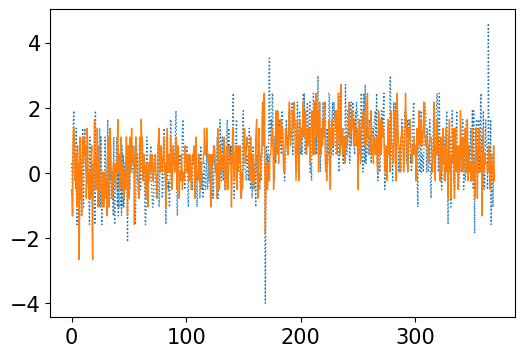

In [13]:
_event = 10

fig, ax = plt.subplots()

ax.plot(data.waveforms['waveTime'][_event,0], 
        data.waveforms['wave'][_event,0], 
        'C0:', lw=1, label='TLU clock'
       )

ax.plot(data.waveforms['waveTime'][_event,1], 
        data.waveforms['wave'][_event,1], 
        'C1-', lw=1, label='TLU trig id'
       )

ax.plot(data.waveforms['waveTime'][_event,0], 
        data.waveforms['trigger'][_event], 
        'C3-', lw=1, label='TLU trigger'
       )

ax.set(title='', xlabel='time [ns]', ylabel='signal', xlim=(200,500))
ax.grid(which='major', lw=0.7, ls='-')
ax.grid(which='minor', lw=0.5, ls=':')
ax.minorticks_on()
ax.legend()

fig.tight_layout(h_pad=1, w_pad=1)
# fig.savefig('tmp.pdf')
plt.show()

In [ ]:
_channel = 0

fig, ax = plt.subplots(1,2)

ax[0].hist(data.waveforms['triggerTime'][:, _channel], bins=100, histtype='step')
ax[1].hist(data.waveforms['cft'][:, _channel], bins=100, histtype='step')

fig.tight_layout(h_pad=1, w_pad=1)
plt.show()